In [50]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [52]:
df=pd.read_csv("shop_smart.csv")

In [54]:
df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


In [56]:
df.isnull().sum()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType           

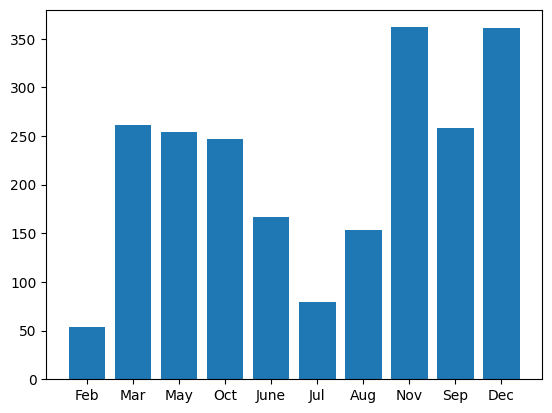

In [58]:
plt.bar(df["Month"],df["PageValues"])
plt.show()

In [61]:
from sklearn.preprocessing import LabelEncoder,OneHotEncoder
le=LabelEncoder()

df["VisitorType"]=le.fit_transform(df["VisitorType"])
df["Weekend"]=le.fit_transform(df["Weekend"])
df["Month"]=le.fit_transform(df["Month"])
df["Revenue"]=le.fit_transform(df["Revenue"])


df.head(10)

## without pruning

In [66]:
from sklearn.model_selection import train_test_split
from sklearn.tree import  DecisionTreeClassifier

from  sklearn.metrics import accuracy_score


X = df.drop(columns=["Revenue"])
Y = df["Revenue"]

X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,random_state=42)

model=DecisionTreeClassifier()
model.fit(X_train,Y_train)

y_pred=model.predict(X_test)

print("accuracy Score:",accuracy_score(Y_test,y_pred))

accuracy Score: 0.8600973236009732


In [68]:
from sklearn.metrics import f1_score

f1 = f1_score(Y_test, y_pred)
print("F1 Score:", f1)


F1 Score: 0.5797807551766139


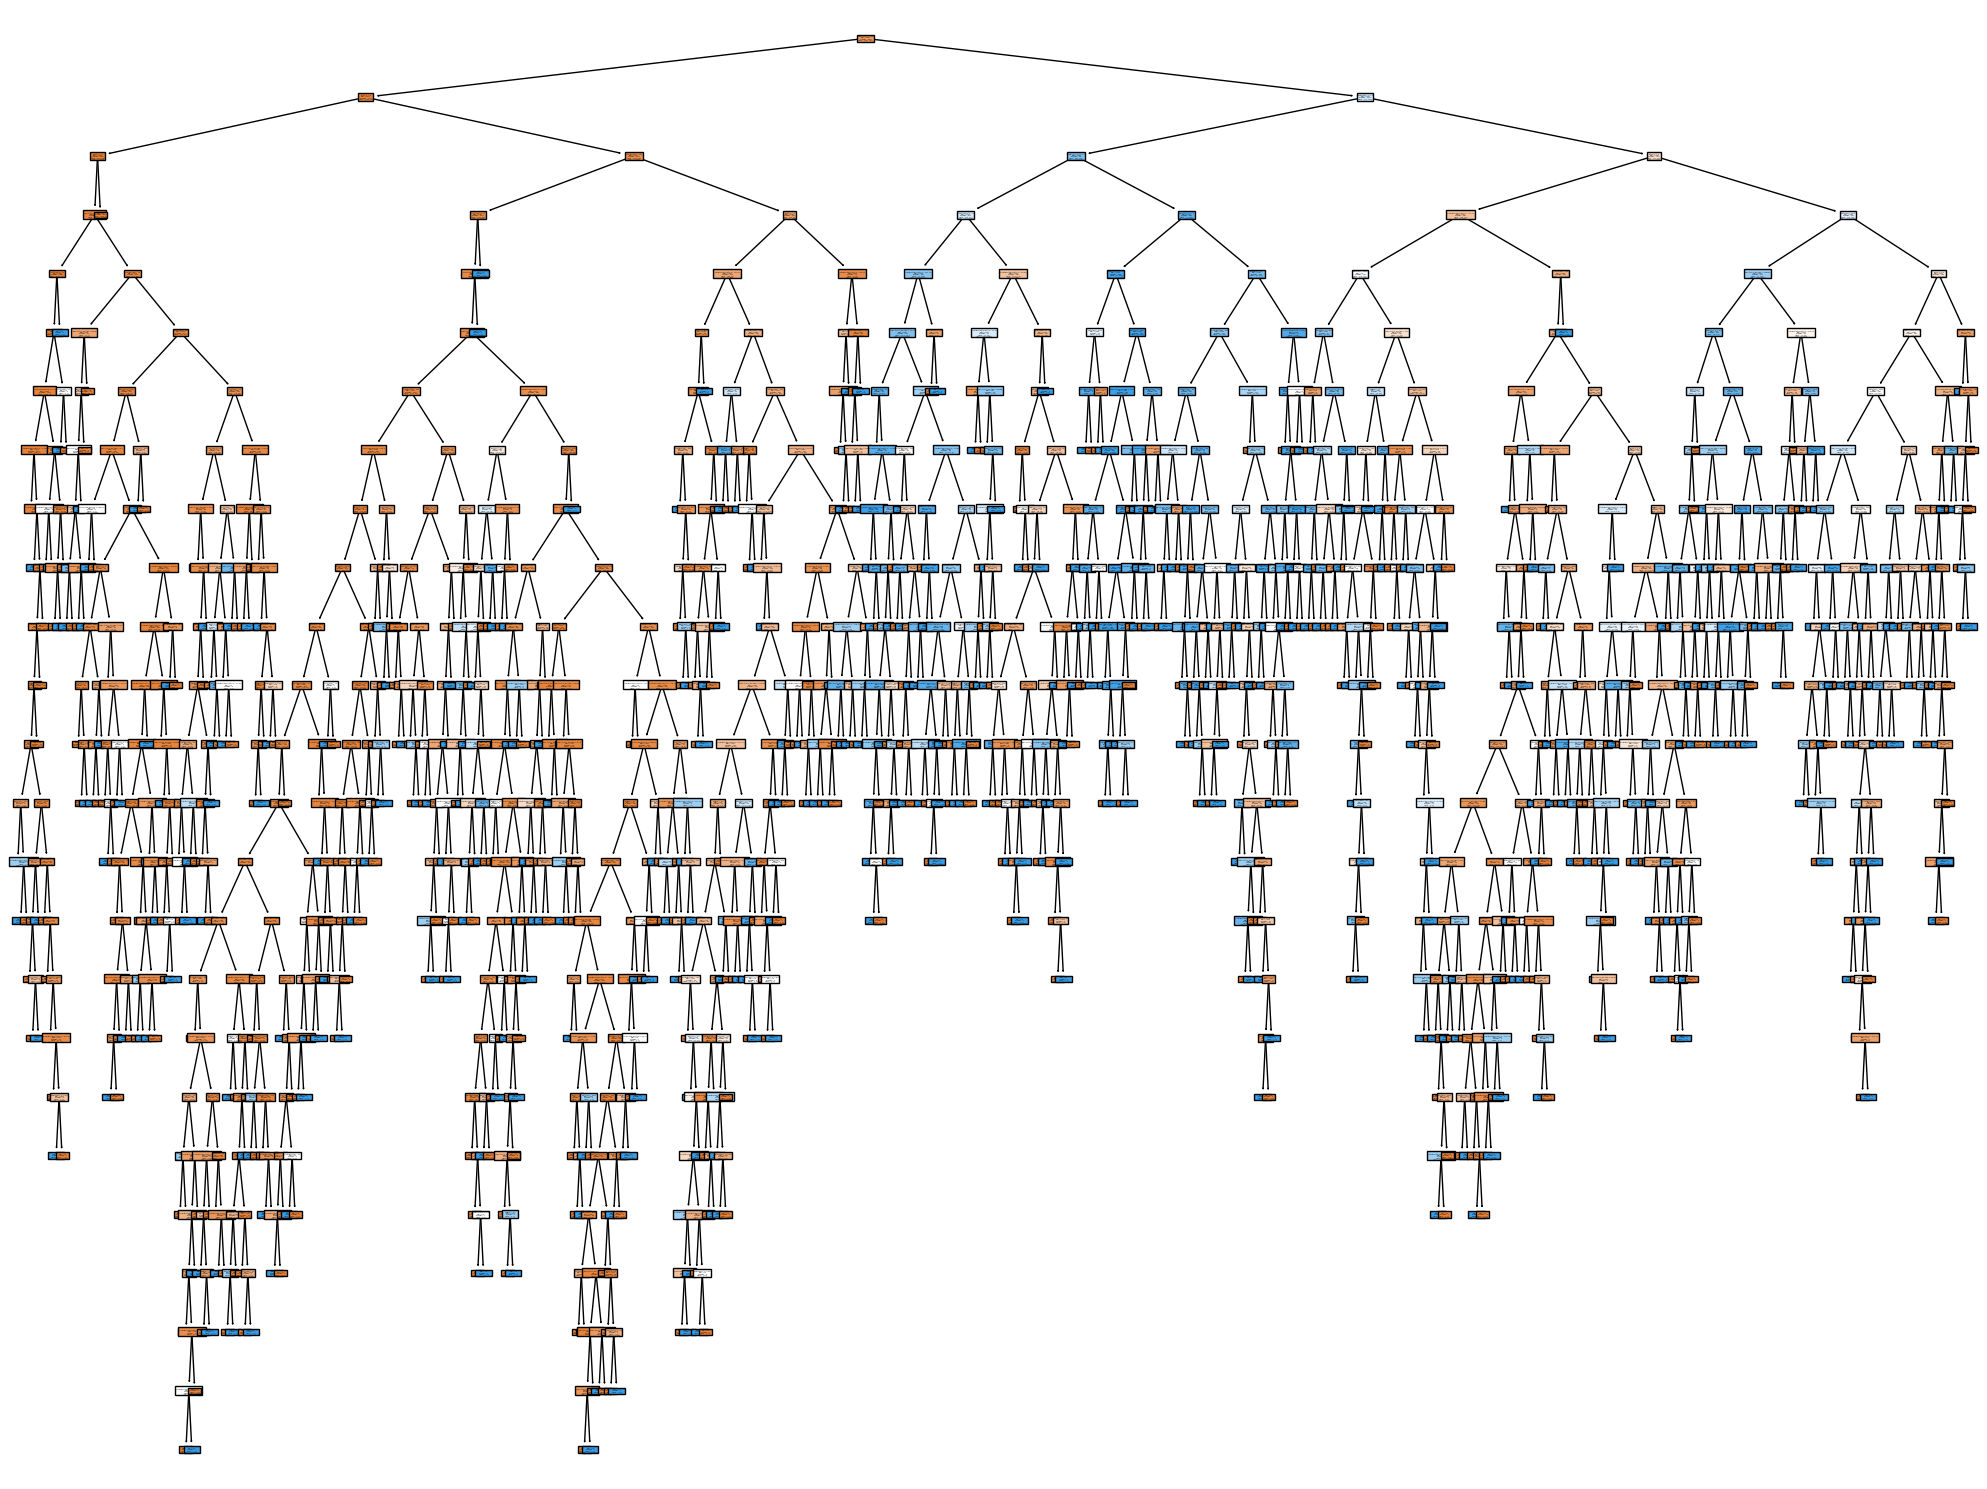

In [81]:
from sklearn.tree import plot_tree
plt.figure(figsize=(20,15))

plot_tree(
    model,
    feature_names=X.columns,
    class_names=["Revenue","not Revenued"],
    filled=True
)
plt.tight_layout()
plt.show()

# with pruning

In [102]:
max_depths=[2,3,4,5,7,9,10,13]
min_sample_split=[10,20,30,50,60,80]
    
for depth in max_depths:
    model=DecisionTreeClassifier(max_depth=depth,random_state=42)
    model.fit(X_train,Y_train)
    
    y_pred=model.predict(X_test)
    acc = accuracy_score(Y_test, y_pred)
    print(f"Accuracy Score for depth={depth} is {acc:.4f}")
    
for split in min_sample_split:
    model=DecisionTreeClassifier(min_samples_split=split,random_state=42)
    model.fit(X_train,Y_train)
    
    y_pred=model.predict(X_test)
    acc = accuracy_score(Y_test, y_pred)
    print(f"Accuracy Score for split={split} is {acc:.4f}")

Accuracy Score for depth=2 is 0.8763
Accuracy Score for depth=3 is 0.8869
Accuracy Score for depth=4 is 0.8885
Accuracy Score for depth=5 is 0.8840
Accuracy Score for depth=7 is 0.8869
Accuracy Score for depth=9 is 0.8885
Accuracy Score for depth=10 is 0.8861
Accuracy Score for depth=13 is 0.8706
Accuracy Score for split=10 is 0.8702
Accuracy Score for split=20 is 0.8771
Accuracy Score for split=30 is 0.8808
Accuracy Score for split=50 is 0.8840
Accuracy Score for split=60 is 0.8856
Accuracy Score for split=80 is 0.8856


In [104]:
model=DecisionTreeClassifier(max_depth=9,min_samples_split=80,random_state=42)
model.fit(X_train,Y_train)
    
y_pred=model.predict(X_test)
acc = accuracy_score(Y_test, y_pred)
print(f"Accuracy Score for depth={depth} is {acc:.4f}")

f1 = f1_score(Y_test, y_pred)
print("F1 Score:", f1)

Accuracy Score for depth=13 is 0.8893
F1 Score: 0.624484181568088


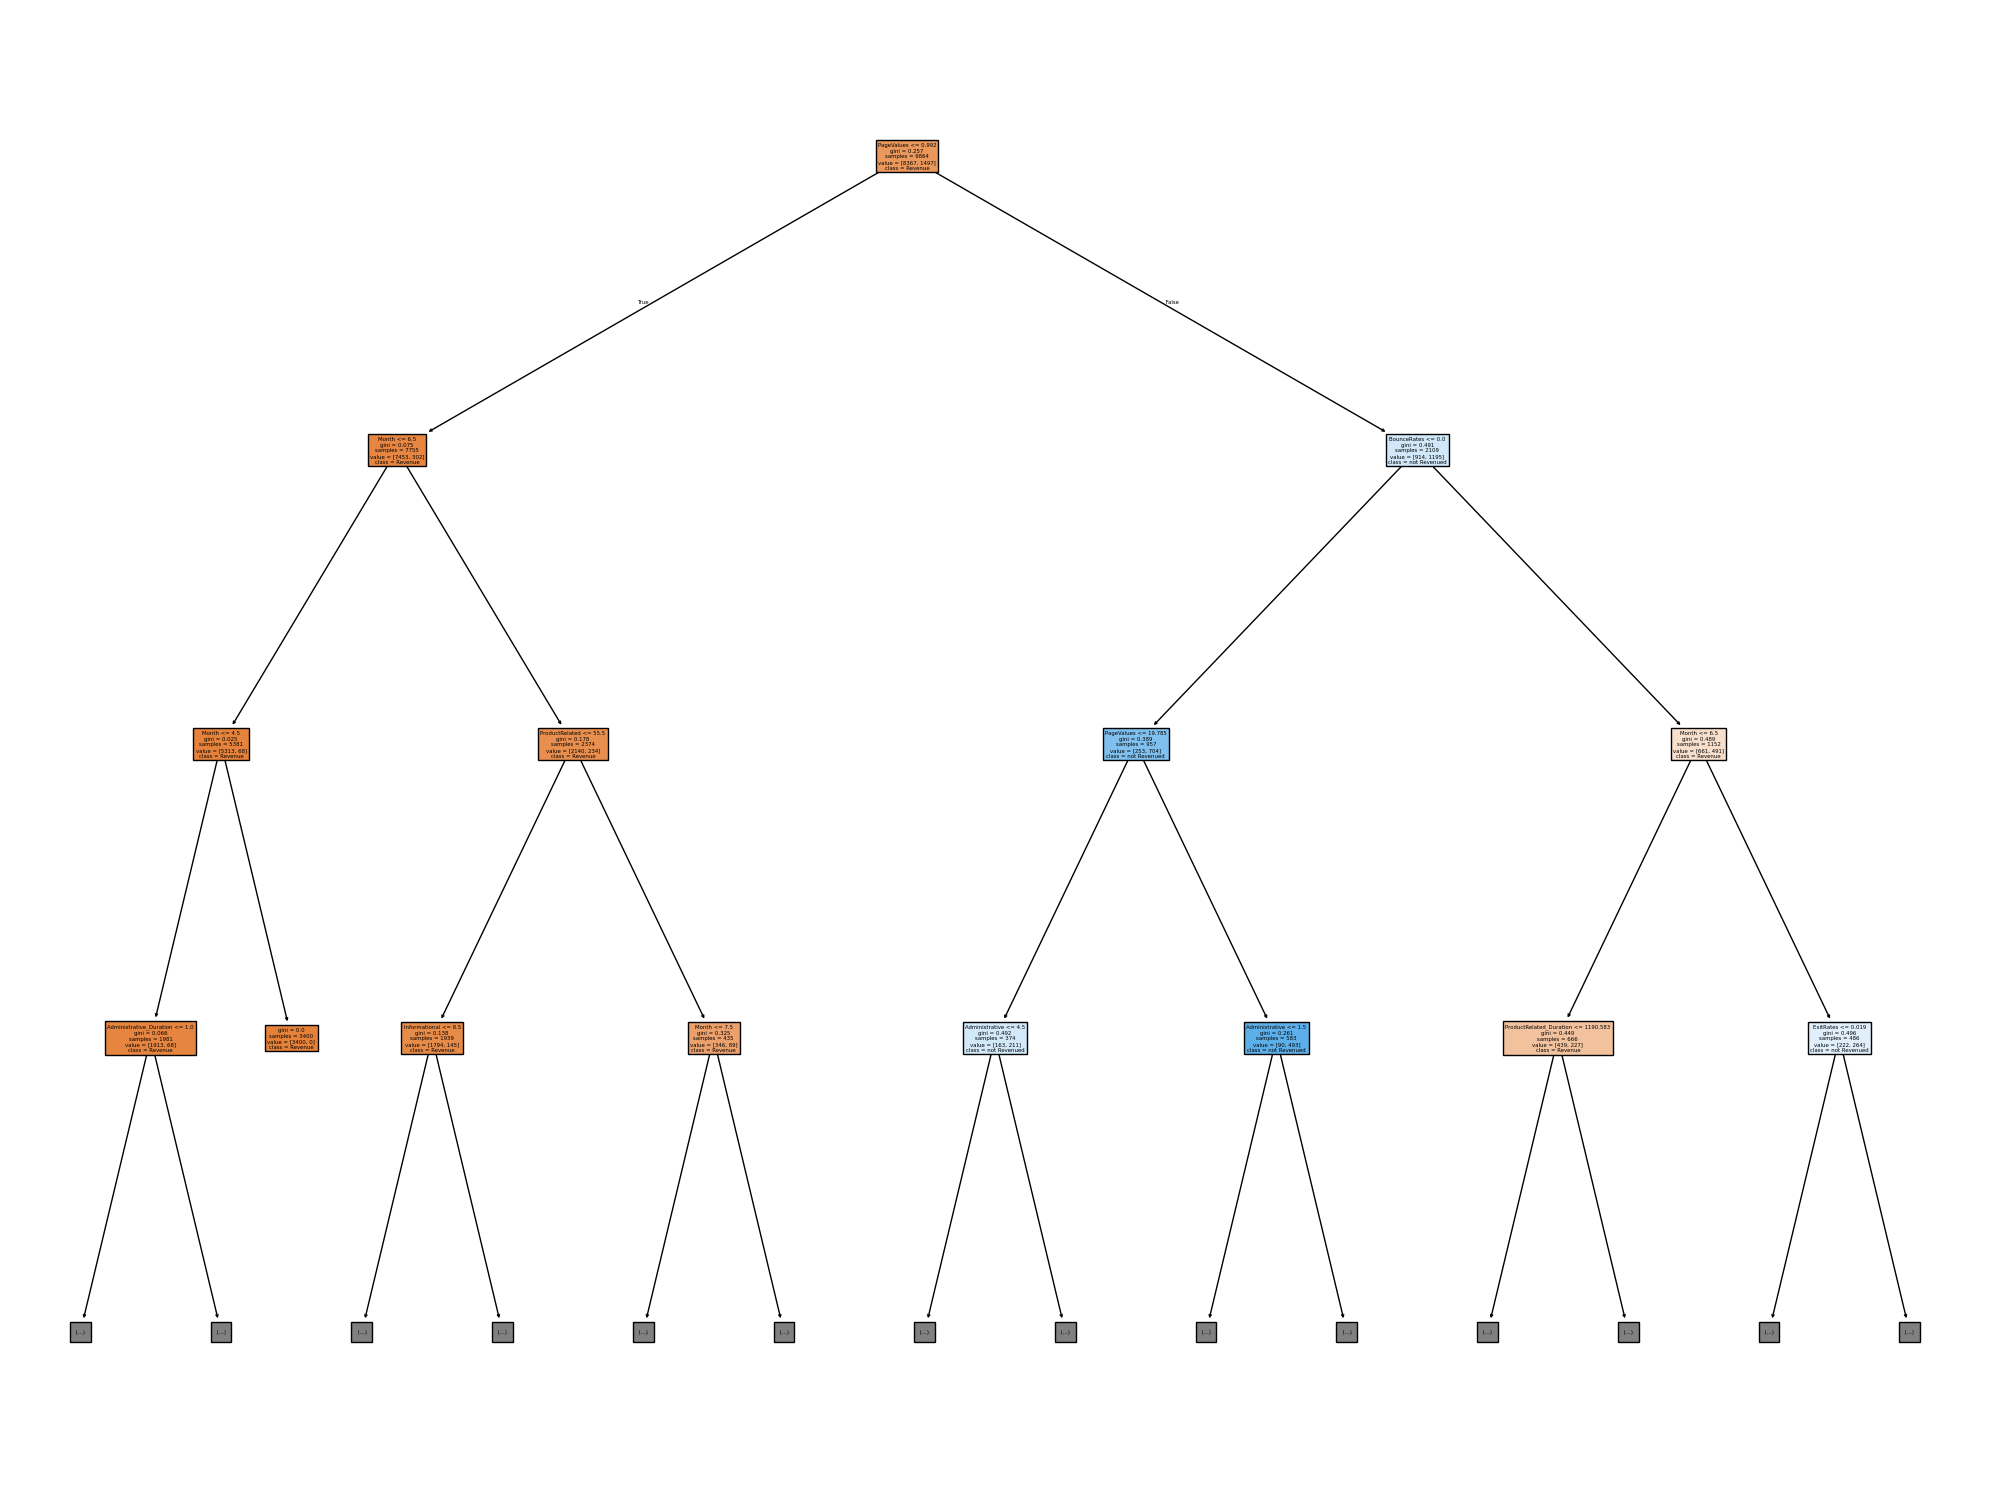

In [108]:
from sklearn.tree import plot_tree
plt.figure(figsize=(20,15))

plot_tree(
    model,
    feature_names=X.columns,
    class_names=["Revenue","not Revenued"],
    filled=True,
    max_depth=3
)
plt.tight_layout()
plt.show()